In [8]:
## aart_func is a file with the functions for the image generation
from aart_func import *
## params have all the important params of the simulation
from params import *
plt.rcParams['text.usetex'] = True

In [10]:
# local paths for loading data and downloading images
path_lensingband17 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i17_dx0.1.h5"
path_lensingband60 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i60_dx0.1.h5"

path_raytracing17 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i17_dx0.1.h5"
path_raytracing60 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i60_dx0.1.h5"

path_images = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\Imagenes"

In [12]:
# Lensing bands params importation for i = 17
fnbands = path_lensingband17
print("reading file:",fnbands)
h5f = h5py.File(fnbands,'r')

#Grid points information for each lensing band
supergrid0=h5f['grid0'][:]
mask0=h5f['mask0'][:]
N0=int(h5f["N0"][0])
lim0=int(h5f["lim0"][0])

supergrid1=h5f['grid1'][:]
mask1=h5f['mask1'][:]
N1=int(h5f["N1"][0])
lim1=int(h5f["lim1"][0])

supergrid2=h5f['grid2'][:]
mask2=h5f['mask2'][:]
N2=int(h5f["N2"][0])
lim2=int(h5f["lim2"][0])

h5f.close()

reading file: C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i17_dx0.1.h5


In [14]:
# Ray tracing params importation for i = 17
fnrays = path_raytracing17
print("Reading file: ",fnrays)
h5f = h5py.File(fnrays,'r')

#We extract all the information from the .h5 file.
rs0=h5f['rs0'][:]
sign0=h5f['sign0'][:]
t0=h5f['t0'][:]
phi0=h5f['phi0'][:]

rs1=h5f['rs1'][:]
sign1=h5f['sign1'][:]
t1=h5f['t1'][:]
phi1=h5f['phi1'][:]

rs2=h5f['rs2'][:]
sign2=h5f['sign2'][:]
t2=h5f['t2'][:]
phi2=h5f['phi2'][:]

h5f.close()

Reading file:  C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i17_dx0.1.h5


In [16]:
path = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\aart_main\inoisy.h5"
print("Reading inoisy file: ",path)

hf = h5py.File(path, 'r')
try:
    data = np.array(hf['data/data_env'])
except:
    data = np.array(hf['data/data_raw'])
#inoisy has periodic boudaries, so we need to copy wrap the data with one frame
data=np.concatenate((data,data[0,:,:][np.newaxis,:,:]),axis=0)

Reading inoisy file:  C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\aart_main\inoisy.h5


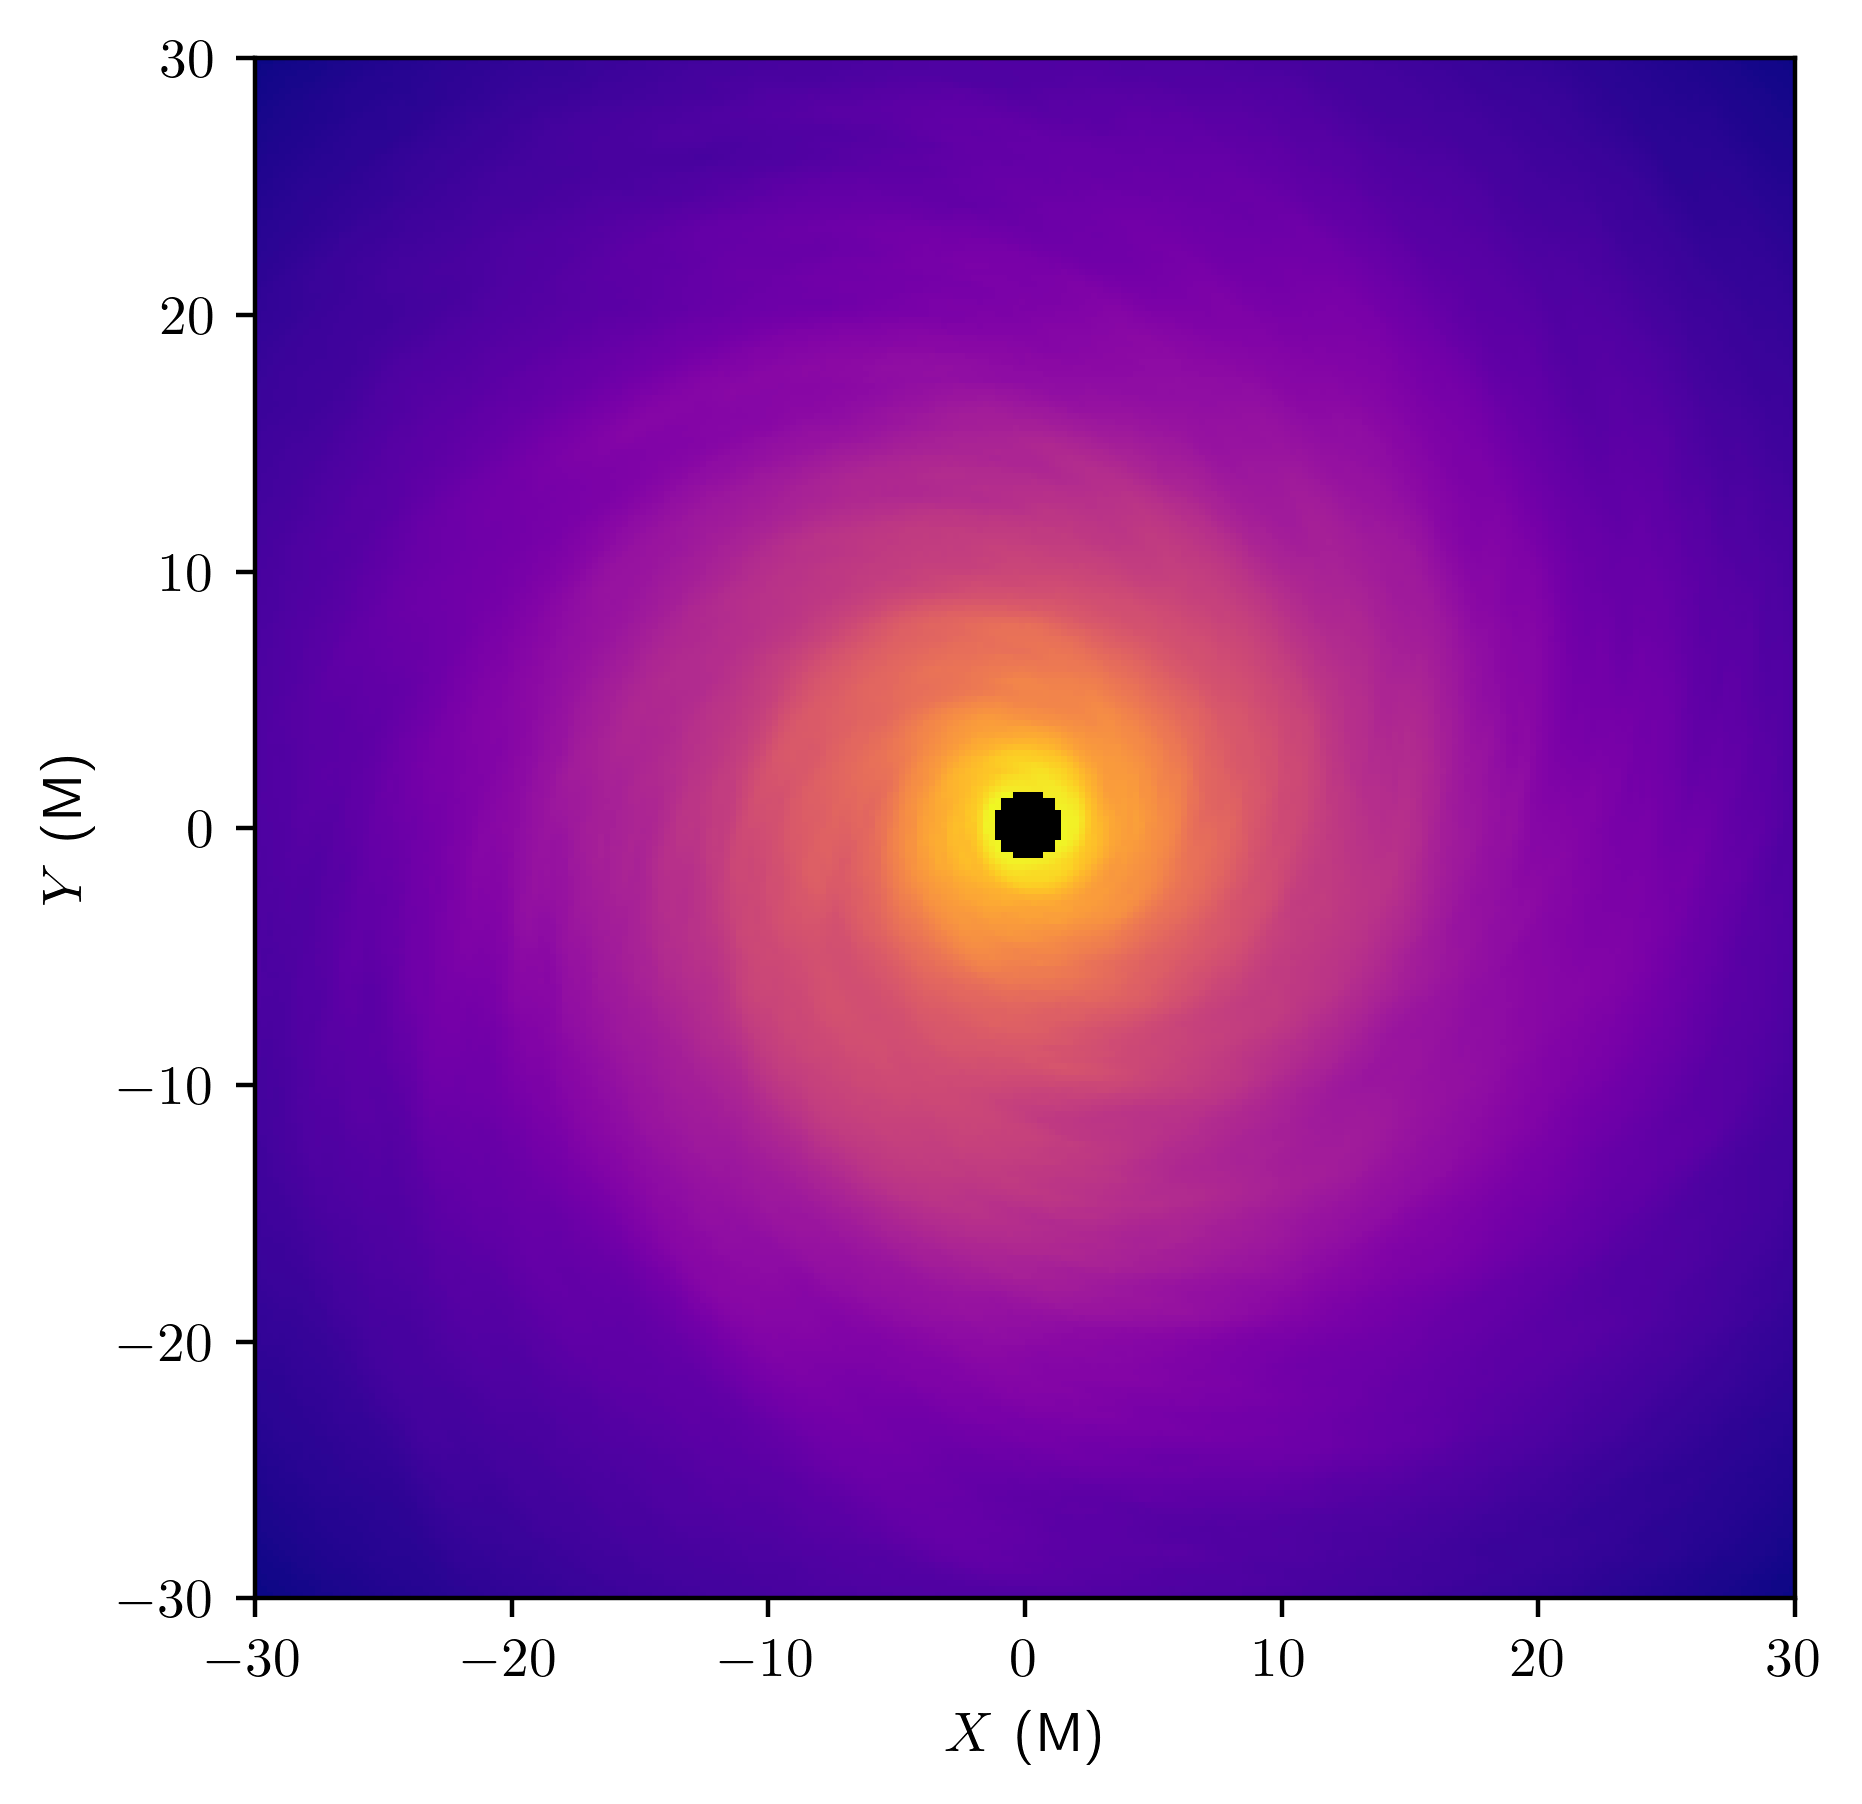

In [18]:
fig, ax = plt.subplots(figsize=[5,5],dpi=400)

#You can select different snapshots by changing the slicing 
ax.imshow(np.log(data[55,:,:]),cmap="plasma",origin="lower",extent=[-30,30,-30,30])

ax.set_facecolor('xkcd:black')
ax.set_xlabel(r"$X$"+" "+"(M)")
ax.set_ylabel(r"$Y$"+" "+"(M)")
#plt.savefig(f'InoisySnapshot.png',dpi=400,bbox_inches='tight')
plt.show()

In [20]:
nt =data.shape[0] #inoisy time resolution
ni = data.shape[1] #inoisy x resolution
nj = data.shape[2] #inoisy y resolution

try: 
	xtstart = np.array(hf['params/x0start'])[0]
	xtend = np.array(hf['params/x0end'])[0]

	x1start = np.array(hf['params/x1start'])[0]
	x2start = np.array(hf['params/x2start'])[0]

	x1end = np.array(hf['params/x1end'])[0]
	x2end = np.array(hf['params/x2end'])[0]

except:
	xtstart = np.array(hf['params/x0start'])
	xtend = np.array(hf['params/x0end'])

	x1start = np.array(hf['params/x1start'])
	x2start = np.array(hf['params/x2start'])

	x1end = np.array(hf['params/x1end'])
	x2end = np.array(hf['params/x2end'])


x1 = np.linspace(x1start, x1end, ni) 
x2 = np.linspace(x2start, x2end, nj)

times = np.linspace(xtstart, xtend, nt)

h5py.File.close(hf)

In [22]:
fact=-(D_obs+2*np.log(D_obs))

t0-=fact
t1-=fact
t2-=fact

i_dt = xtend/nt
timeconversion=i_dt*MMkg*Gc/cc**3/(3600*24) # [days]

interpolated3_R=RegularGridInterpolator((times,x1,x2),data,fill_value=0,bounds_error=False,method='linear')

In [78]:
import numpy as np
from scipy.stats import gaussian_kde

def modal_hdi_kde(data, p=0.68, gridsize=4000):
    """
    Compute a modal highest-density interval (HDI) from a kernel density estimate (KDE).
    This function estimates the probability density of the input data using a Gaussian
    KDE, identifies the mode as the location of maximum estimated density, and then
    finds the connected interval around that mode that contains approximately a target
    probability mass `p`.
    :param data: One-dimensional sample of data points.
    :param p: Target probability mass to be enclosed by the modal HDI. Must be between 0 and 1.
    :param gridsize: Number of grid points used to evaluate the KDE between the minimum and maximum of the data.
    
    :returns: A tuple containing:
              - mode: location of the KDE mode
              - left: left boundary of the modal HDI
              - right: right boundary of the modal HDI
              - width: interval width, computed as right - left
              - mass: approximate probability mass enclosed in the interval
              - threshold: density threshold defining the interval
    """
    data = np.asarray(data)
    # Filtrar valores no finitos
    data_finite = data[np.isfinite(data)]
    
    kde = gaussian_kde(data_finite)
    xgrid = np.linspace(data_finite.min(), data_finite.max(), gridsize)
    dens = kde(xgrid)

    dx = xgrid[1] - xgrid[0]
    probs = dens * dx
    mode_idx = np.argmax(dens)
    mode = xgrid[mode_idx]
    
    # Binary search over the density threshold
    lo, hi = 0.0, dens[mode_idx]

    best = None

    for _ in range(60):
        c = (lo + hi) / 2.0
        mask = dens >= c

        # Connected component containing the mode
        if not mask[mode_idx]:
            hi = c
            continue

        i = mode_idx
        l = i
        while l > 0 and mask[l - 1]:
            l -= 1
        r = i
        while r < len(mask) - 1 and mask[r + 1]:
            r += 1

        mass = probs[l:r+1].sum()

        if mass >= p:
            lo = c
            best = (mode, xgrid[l], xgrid[r], xgrid[r] - xgrid[l],  mass, c)
        else:
            hi = c

    return best  # (mode, left, right, width = right - left, mass, threshold)


In [110]:
p_b = 0.9
mode0, left0, right0, _, mass00, _ = modal_hdi_kde_err(t0, p_b)
mode1, left1, right1, _, mass01, _ = modal_hdi_kde_err(t1, p_b)
mode2, left2, right2, _, mass02, _ = modal_hdi_kde_err(t2, p_b)

In [ ]:
print(mass00,mass01,mass02)

In [96]:
minV = 0
maxV = 99.95

t0_renorm_17 = t0 
valid_mask = np.isfinite(t0_renorm_17)
t0_renorm_17 = t0_renorm_17[valid_mask]
T0min17, T0max17 = np.percentile(t0_renorm_17, [minV,maxV])
mask_in_range_17 = (t0_renorm_17 >= T0min17) & (t0_renorm_17 <= T0max17 )
t0_renorm_17 = t0_renorm_17[mask_in_range_17]

minV = 5
maxV = 99.95

t1_renorm_17 = t1 
valid_mask = np.isfinite(t1_renorm_17)
t1_renorm_17 = t1_renorm_17[valid_mask]
T1min17, T1max17 = np.percentile(t1_renorm_17, [minV,maxV])
mask_in_range_17 = (t1_renorm_17 >= T1min17) & (t1_renorm_17 <= T1max17 )
t1_renorm_17 = t1_renorm_17[mask_in_range_17]

t2_renorm_17 = t2 
valid_mask = np.isfinite(t2_renorm_17)
t2_renorm_17 = t2_renorm_17[valid_mask]
T2min17, T2max17 = np.percentile(t2_renorm_17, [minV,maxV])
mask_in_range_17 = (t2_renorm_17 >= T2min17) & (t2_renorm_17 <= T2max17 )
t2_renorm_17 = t2_renorm_17[mask_in_range_17]

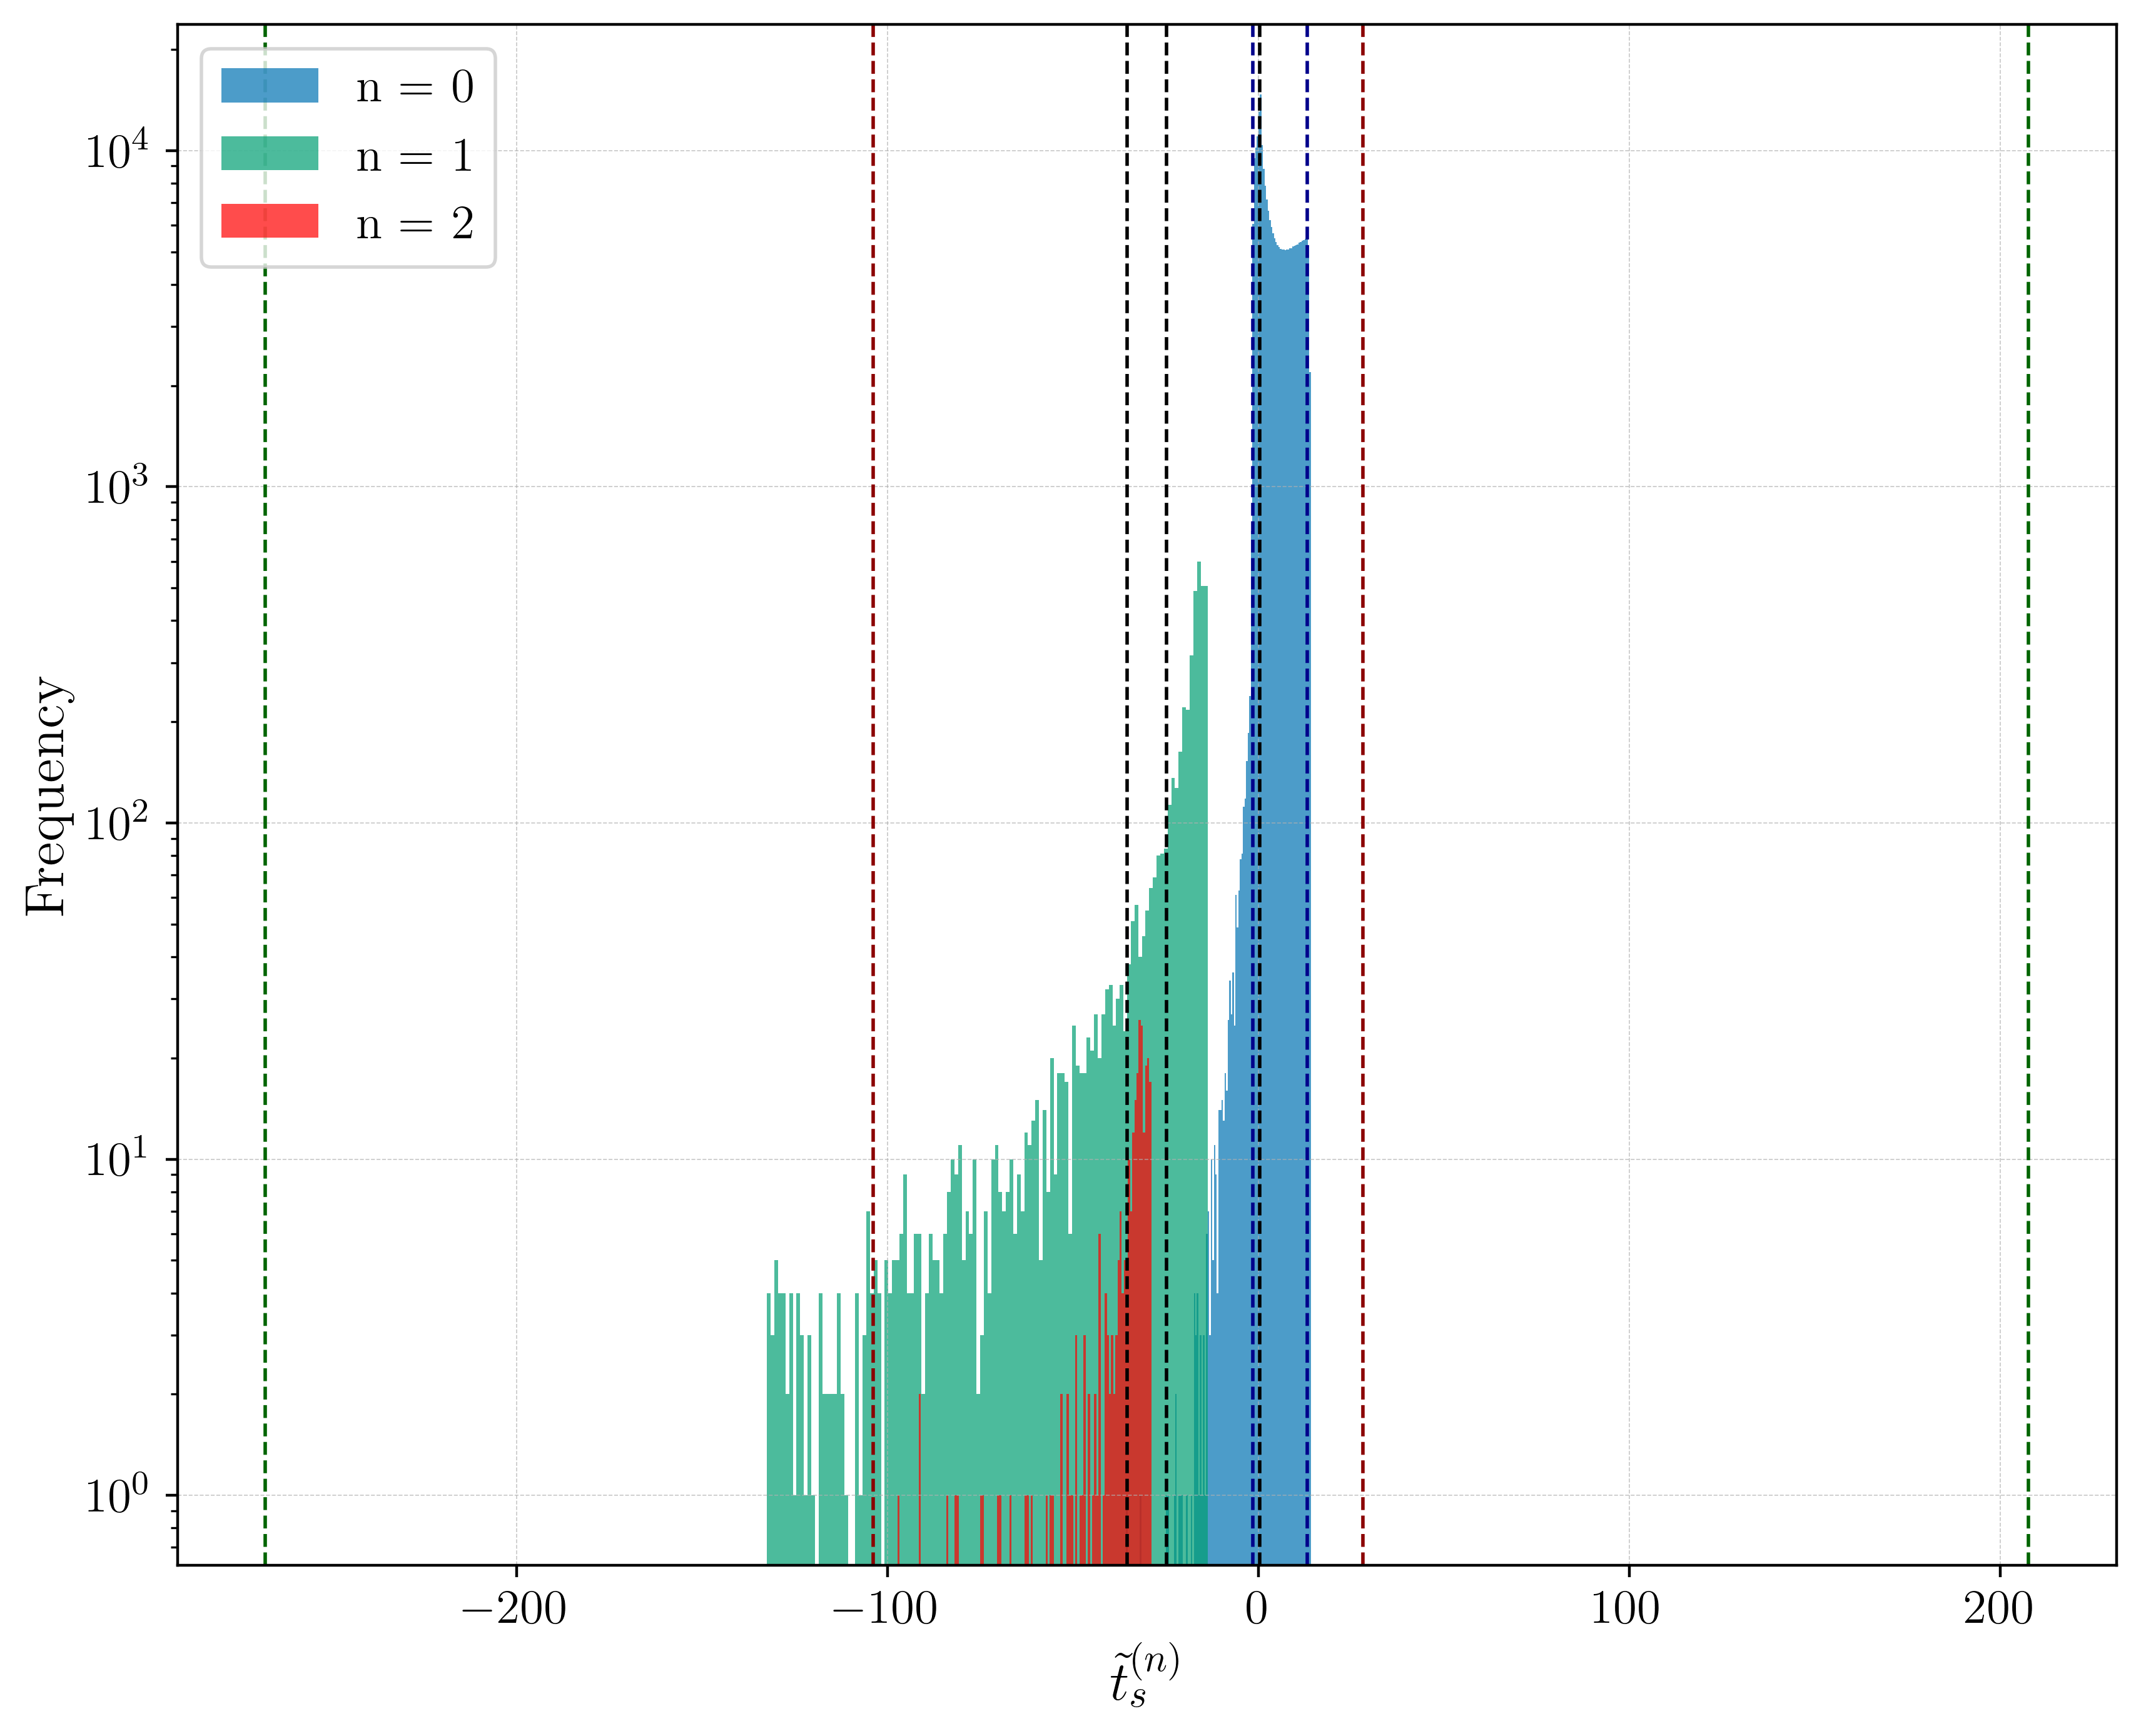

In [113]:
import matplotlib as mpl
import matplotlib.pyplot as plt

#Only if LaTeX is configured locally
mpl.rcParams['text.usetex'] = True  
mpl.rcParams['font.family'] = 'serif'

# Create the normalized histogram
plt.figure(figsize=[10,8], dpi=400)


plt.hist(t0_renorm_17, bins=120, color='#0072B2', label=r"n = 0", density=False, alpha=0.7)
plt.axvline(x=mode0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=left0, color='darkblue', linestyle='--', linewidth=1)
plt.axvline(x=right0, color='darkblue', linestyle='--', linewidth=1)


plt.hist(t1_renorm_17, bins=120, color='#009E73', label=r"n = 1", density=False, alpha=0.7)
plt.axvline(x=mode1, color='black', linestyle='--', linewidth=1)
plt.axvline(x=left1, color='darkgreen', linestyle='--', linewidth=1)
plt.axvline(x=right1, color='darkgreen', linestyle='--', linewidth=1)


plt.hist(t2_renorm_17, bins=120, color='red', label=r"n = 2", density=False, alpha=0.7)
plt.axvline(x=mode2, color='black', linestyle='--', linewidth=1)
plt.axvline(x=left2, color='darkred', linestyle='--', linewidth=1)
plt.axvline(x=right2, color='darkred', linestyle='--', linewidth=1)


plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)

plt.yscale("log")
plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel(r'$\tilde{t}_s^{(n)}$', fontsize=16)
#plt.xlim(-150,20)
plt.ylabel(r'$\mathrm{Frequency}$', fontsize=16)

plt.show()

In [ ]:
def brisk_light(mask, ts, left_s, right_s):

    ts = ts[mask]

    time_mask = obsint.periodic_interval_mask(ts, left_s, right_s)

    #cond_disk = (rs >= isco)
    #cond_gas  = (rs < isco)

    #interp_disk = cond_disk & time_mask
    #interp_gas  = cond_gas & time_mask

    ts = ts[time_mask]
    return ts

In [ ]:
tsnap = 100
ts0 = np.mod(t0 + tsnap, xtend)
ts1 = np.mod(t1 + tsnap, xtend)
ts2 = np.mod(t2 + tsnap, xtend)

print(f"n = 0: Min = {np.nanmin(ts0)}, Max = {np.nanmax(ts0)} ")
print(f"n = 1: Min = {np.nanmin(ts1)}, Max = {np.nanmax(ts1)} ")
print(f"n = 2: Min = {np.nanmin(ts2)}, Max = {np.nanmax(ts2)} ")

In [28]:
mode0_snap = np.mod(mode0 + tsnap, xtend)
left0_snap = np.mod(left0 + tsnap, xtend)
right0_snap= np.mod(right0 + tsnap, xtend)

mode1_snap = np.mod(mode1 + tsnap, xtend)
left1_snap = np.mod(left1 + tsnap, xtend)
right1_snap= np.mod(right1 + tsnap, xtend)

mode2_snap = np.mod(mode2 + tsnap, xtend)
left2_snap = np.mod(left2 + tsnap, xtend)
right2_snap= np.mod(right2 + tsnap, xtend)

ts0m = brisk_light(mask0,ts0,left0_snap,right0_snap)
ts1m = brisk_light(mask1,ts1,left1_snap,right1_snap)
ts2m = brisk_light(mask2,ts2,left2_snap,right2_snap)


print('Lower and upper time of the source movie')
print(f"n = 0: Min = {np.nanmin(ts0m)}, Max = {np.nanmax(ts0m)} ")
print(f"n = 1: Min = {np.nanmin(ts1m)}, Max = {np.nanmax(ts1m)} ")
print(f"n = 2: Min = {np.nanmin(ts2m)}, Max = {np.nanmax(ts2m)} ")

NameError: name 'tsnap' is not defined

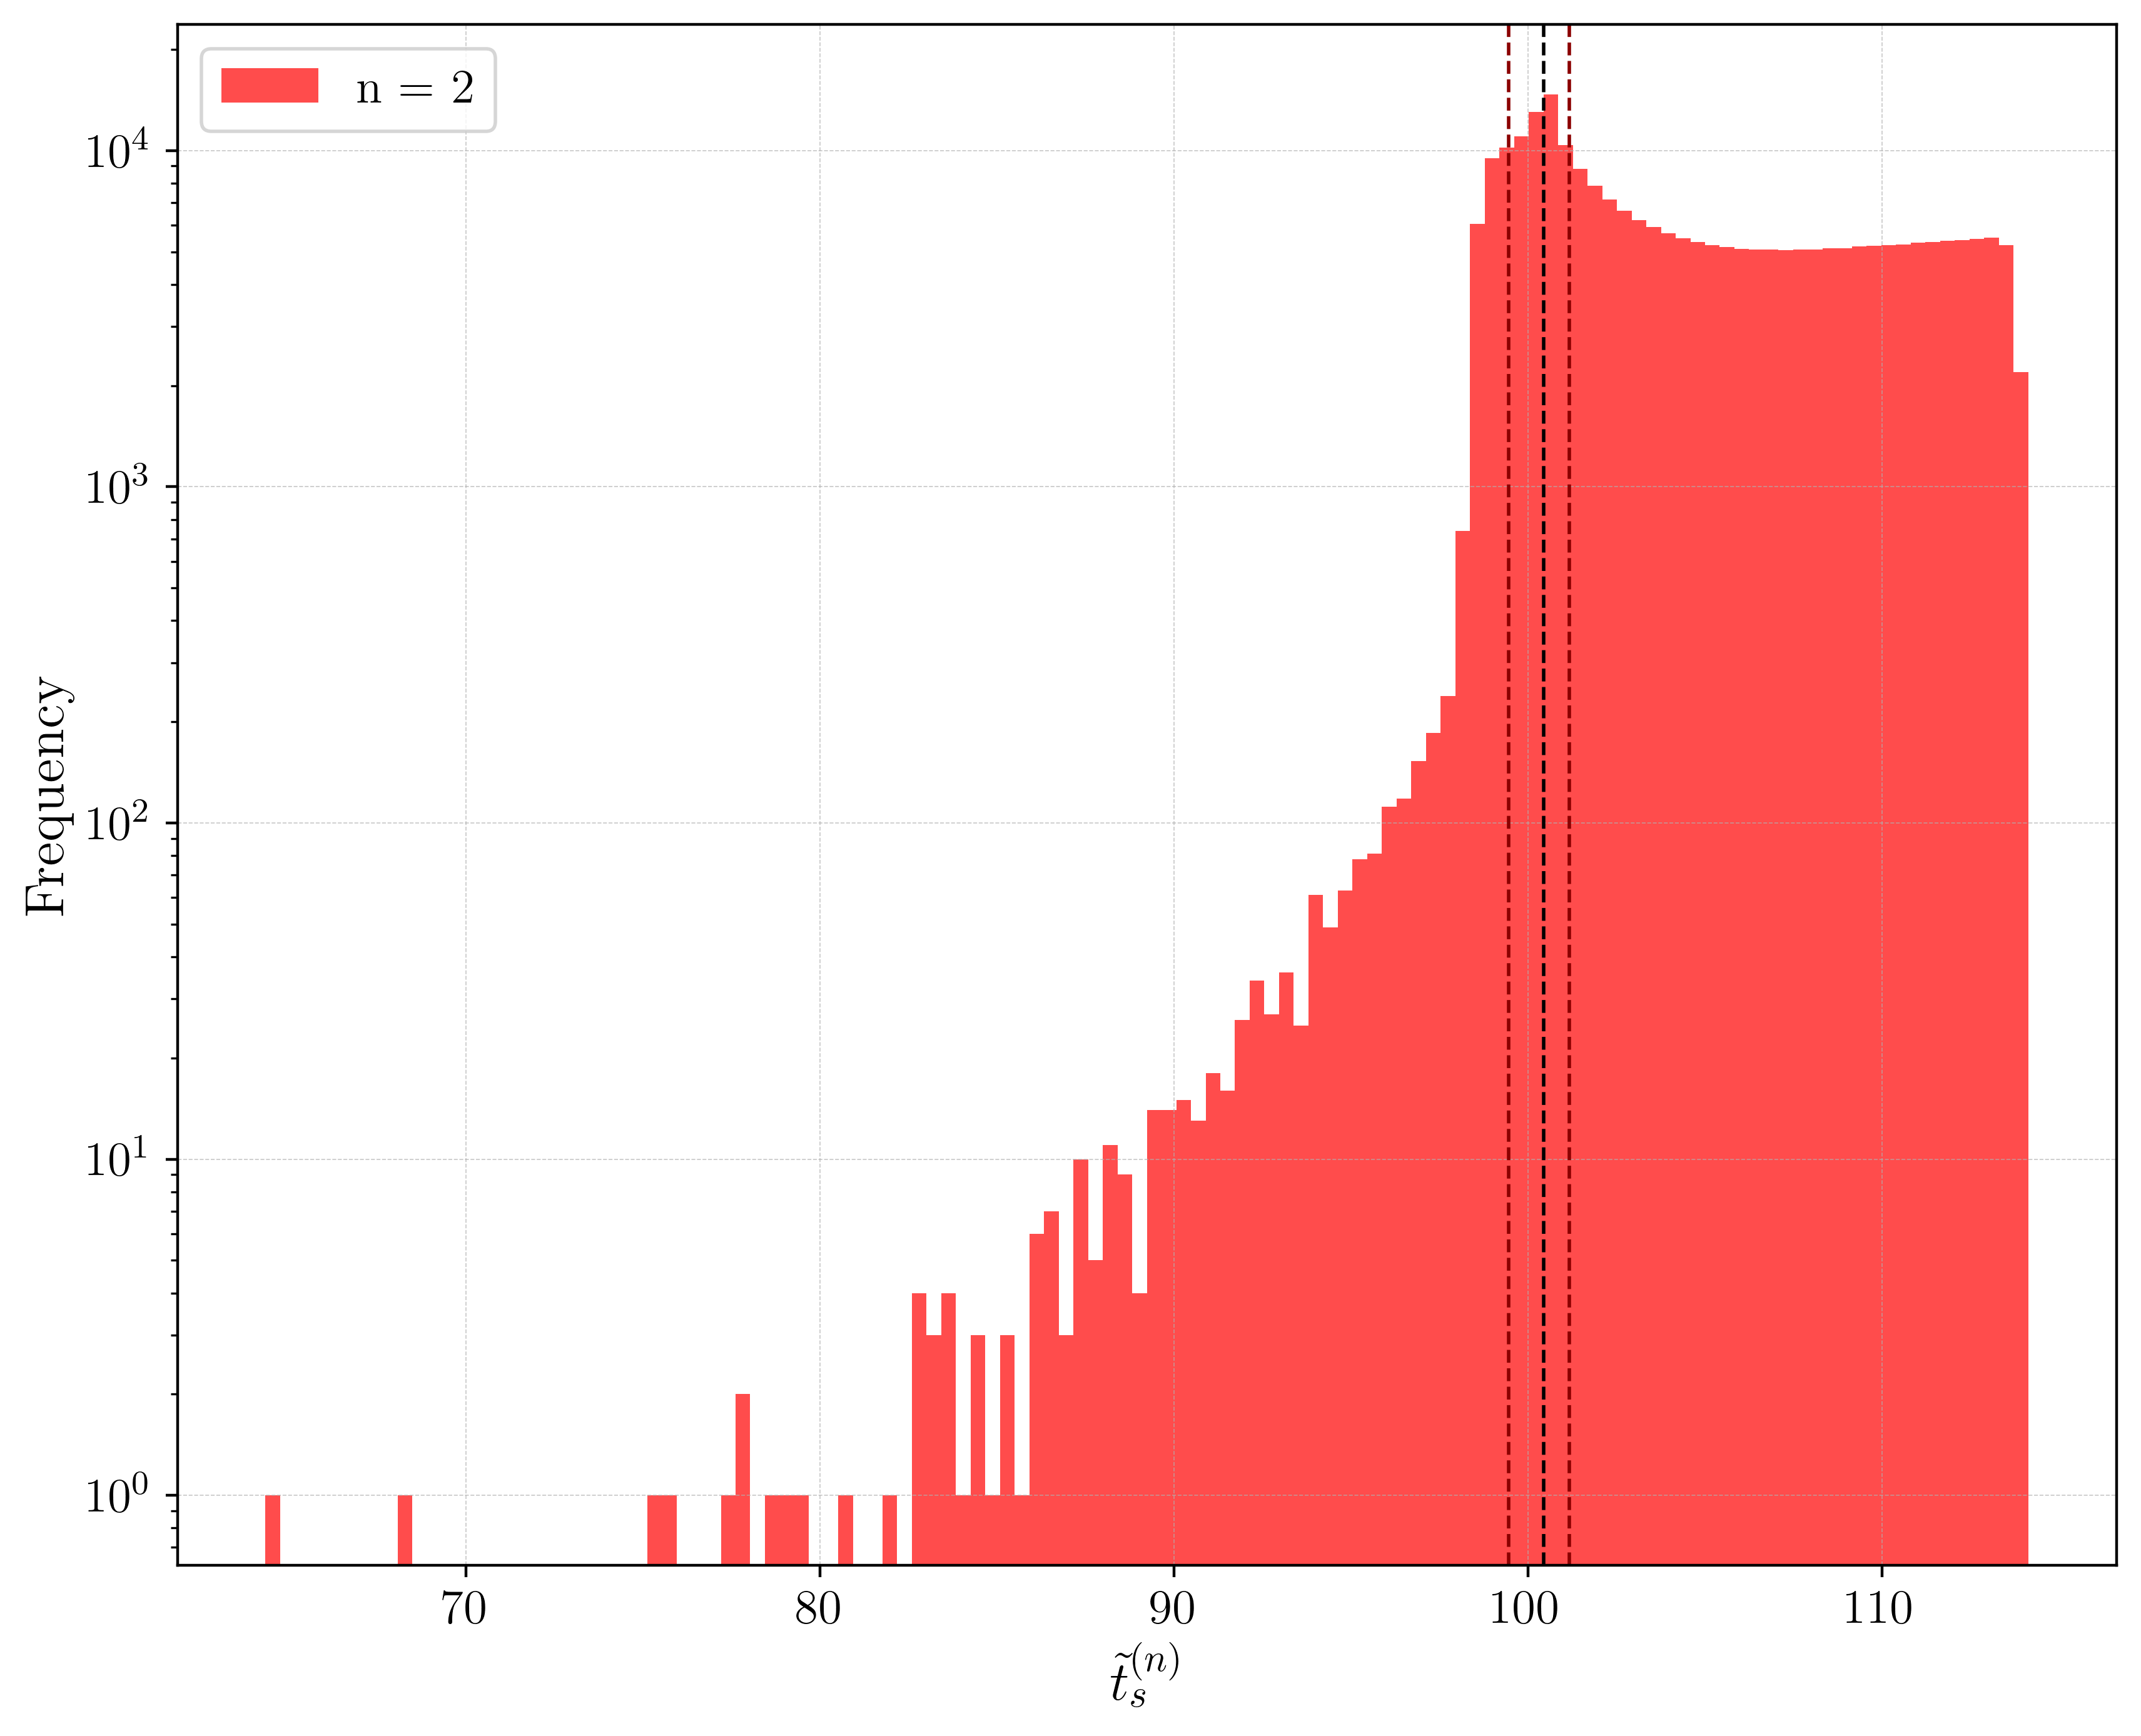

In [34]:
minV = 0
maxV = 99.95

t0_renorm_17 = ts0 
valid_mask = np.isfinite(t0_renorm_17)
t0_renorm_17 = t0_renorm_17[valid_mask]
T0min17, T0max17 = np.percentile(t0_renorm_17, [minV,maxV])
mask_in_range_17 = (t0_renorm_17 >= T0min17) & (t0_renorm_17 <= T0max17 )
t0_renorm_17 = t0_renorm_17[mask_in_range_17]

minV = 5
maxV = 99.95

t1_renorm_17 = ts1 
valid_mask = np.isfinite(t1_renorm_17)
t1_renorm_17 = t1_renorm_17[valid_mask]
T1min17, T1max17 = np.percentile(t1_renorm_17, [minV,maxV])
mask_in_range_17 = (t1_renorm_17 >= T1min17) & (t1_renorm_17 <= T1max17 )
t1_renorm_17 = t1_renorm_17[mask_in_range_17]

t2_renorm_17 = ts2 
valid_mask = np.isfinite(t2_renorm_17)
t2_renorm_17 = t2_renorm_17[valid_mask]
T2min17, T2max17 = np.percentile(t2_renorm_17, [minV,maxV])
mask_in_range_17 = (t2_renorm_17 >= T2min17) & (t2_renorm_17 <= T2max17 )
t2_renorm_17 = t2_renorm_17[mask_in_range_17]

import matplotlib as mpl
import matplotlib.pyplot as plt

#Only if LaTeX is configured locally
mpl.rcParams['text.usetex'] = True  
mpl.rcParams['font.family'] = 'serif'

# Create the normalized histogram
plt.figure(figsize=[10,8], dpi=400)


#plt.hist(t0_renorm_17, bins=120, color='#0072B2', label=r"n = 0", density=False, alpha=0.7)
#plt.axvline(x=mode0, color='black', linestyle='--', linewidth=1)
#plt.axvline(x=left0, color='darkblue', linestyle='--', linewidth=1)
#plt.axvline(x=right0, color='darkblue', linestyle='--', linewidth=1)


#plt.hist(t1_renorm_17, bins=120, color='#009E73', label=r"n = 1", density=False, alpha=0.7)
#plt.axvline(x=mode1, color='black', linestyle='--', linewidth=1)
#plt.axvline(x=left1, color='darkgreen', linestyle='--', linewidth=1)
#plt.axvline(x=right1, color='darkgreen', linestyle='--', linewidth=1)


plt.hist(t0_renorm_17, bins=120, color='red', label=r"n = 2", density=False, alpha=0.7)
plt.axvline(x=mode0_snap, color='black', linestyle='--', linewidth=1)
plt.axvline(x=left0_snap, color='darkred', linestyle='--', linewidth=1)
plt.axvline(x=right0_snap, color='darkred', linestyle='--', linewidth=1)

#plt.axvline(x=tsnap, color='darkgreen', linestyle='--', linewidth=1)
#plt.axvline(x=tsnap-widthleft0, color='green', linestyle='--', linewidth=1)
#plt.axvline(x=tsnap+widthright0, color='green', linestyle='--', linewidth=1)

plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)

plt.yscale("log")
plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel(r'$\tilde{t}_s^{(n)}$', fontsize=16)
plt.ylabel(r'$\mathrm{Frequency}$', fontsize=16)
#plt.xlim(38,56)

plt.show()

In [19]:
shift_01 = int(np.round((mode1 - mode0)))
shift_02 = int(np.round((mode2 - mode0)))

k0 = tsnap
k1 = (k0 + shift_01) % (nt - 1)
k2 = (k0 + shift_02) % (nt - 1)

k0,k1,k2

(100, 67, 64)

In [21]:
dt_src = times[1] - times[0]

shift_01 = mode1 - mode0
shift_02 = mode2 - mode0

k0 = tsnap
k1 = (k0 + shift_01) 
k2 = (k0 + shift_02) 


print(f"tiempos de producción corridos: \n n=0: {k0}, n=1 {k1}, n=2 {k2}")
print(f"modas de la distribución en la fuente: \n n=0: {mode0_snap}, n=1 {mode1_snap}, n=2 {mode2_snap}")

tiempos de producción corridos: 
 n=0: 100, n=1 67.12320504233949, n=2 64.24817881227946
modas de la distribución en la fuente: 
 n=0: 100.4441575544507, n=1 67.56736259679019, n=2 64.69233636673016


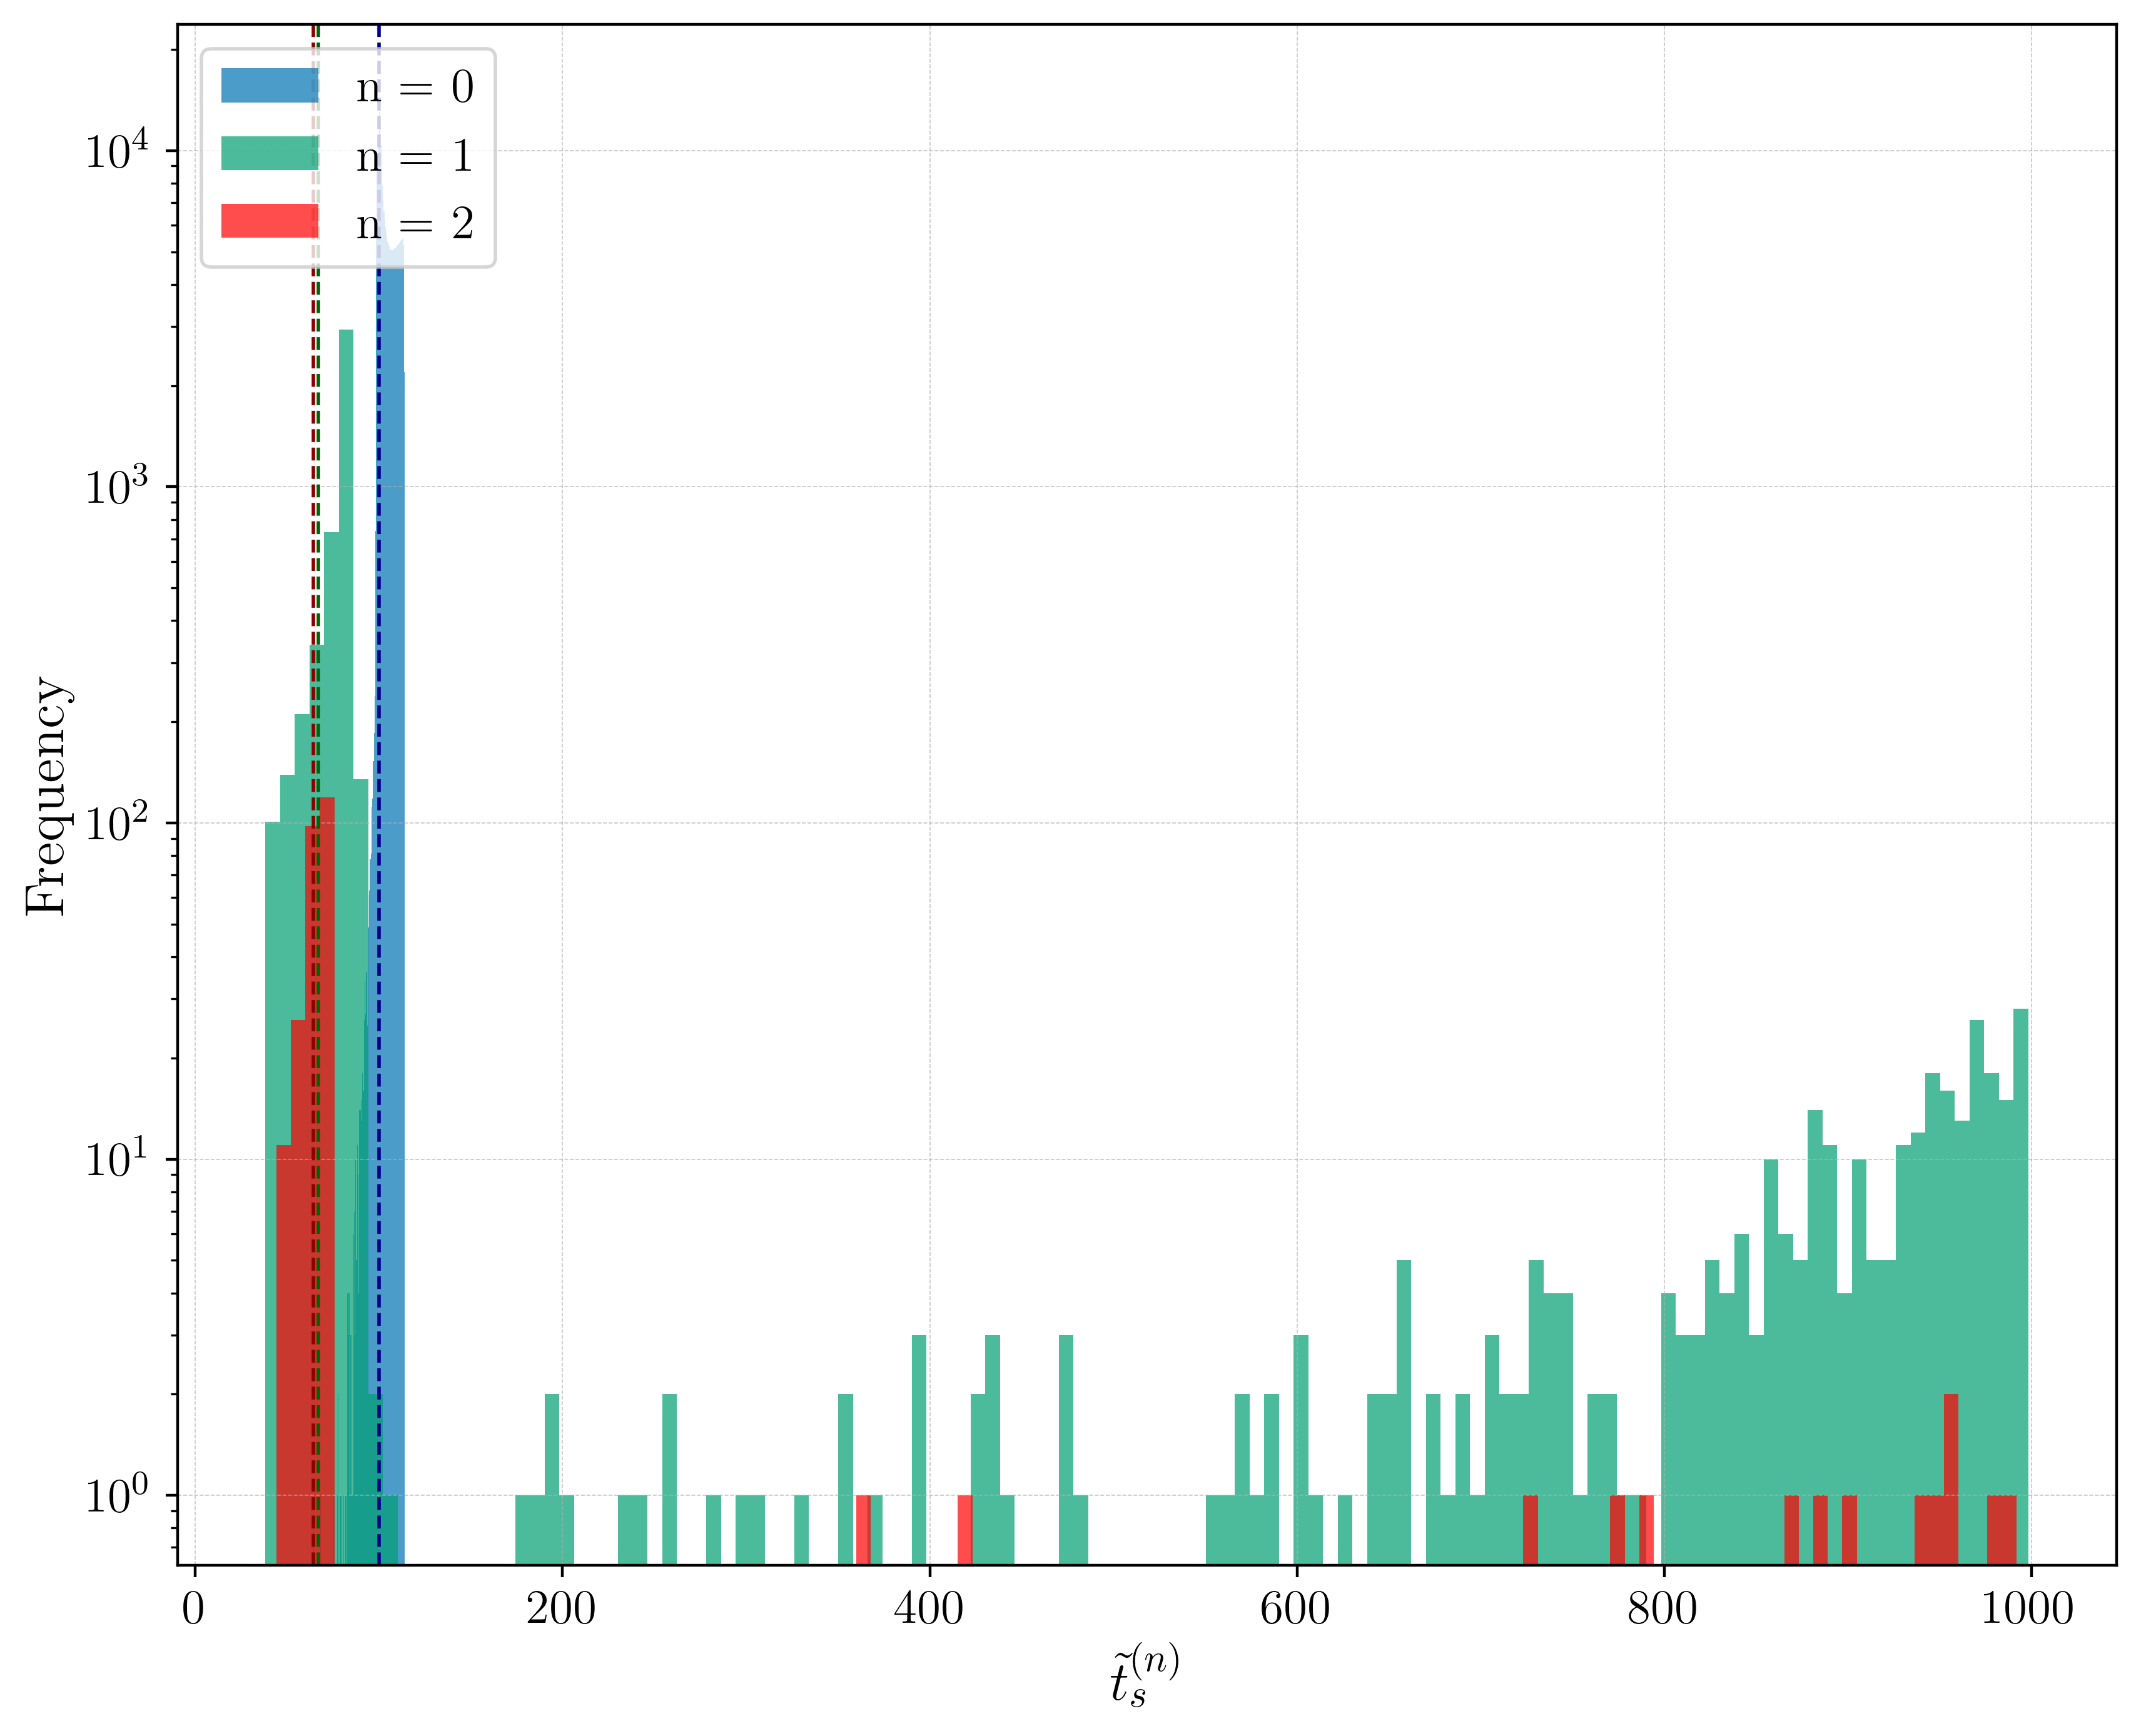

In [23]:
minV = 0
maxV = 99.95

t0_renorm_17 = ts0 
valid_mask = np.isfinite(t0_renorm_17)
t0_renorm_17 = t0_renorm_17[valid_mask]
T0min17, T0max17 = np.percentile(t0_renorm_17, [minV,maxV])
mask_in_range_17 = (t0_renorm_17 >= T0min17) & (t0_renorm_17 <= T0max17 )
t0_renorm_17 = t0_renorm_17[mask_in_range_17]

minV = 5
maxV = 99.95

t1_renorm_17 = ts1 
valid_mask = np.isfinite(t1_renorm_17)
t1_renorm_17 = t1_renorm_17[valid_mask]
T1min17, T1max17 = np.percentile(t1_renorm_17, [minV,maxV])
mask_in_range_17 = (t1_renorm_17 >= T1min17) & (t1_renorm_17 <= T1max17 )
t1_renorm_17 = t1_renorm_17[mask_in_range_17]

t2_renorm_17 = ts2 
valid_mask = np.isfinite(t2_renorm_17)
t2_renorm_17 = t2_renorm_17[valid_mask]
T2min17, T2max17 = np.percentile(t2_renorm_17, [minV,maxV])
mask_in_range_17 = (t2_renorm_17 >= T2min17) & (t2_renorm_17 <= T2max17 )
t2_renorm_17 = t2_renorm_17[mask_in_range_17]

import matplotlib as mpl
import matplotlib.pyplot as plt

#Only if LaTeX is configured locally
mpl.rcParams['text.usetex'] = True  
mpl.rcParams['font.family'] = 'serif'

# Create the normalized histogram
plt.figure(figsize=[10,8], dpi=400)


plt.hist(t0_renorm_17, bins=120, color='#0072B2', label=r"n = 0", density=False, alpha=0.7)


plt.hist(t1_renorm_17, bins=120, color='#009E73', label=r"n = 1", density=False, alpha=0.7)


plt.hist(t2_renorm_17, bins=120, color='red', label=r"n = 2", density=False, alpha=0.7)



plt.axvline(x=k0, color='darkblue', linestyle='--', linewidth=1)
plt.axvline(x=k1, color='darkgreen', linestyle='--', linewidth=1)
plt.axvline(x=k2, color='darkred', linestyle='--', linewidth=1)


plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)

plt.yscale("log")
plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel(r'$\tilde{t}_s^{(n)}$', fontsize=16)
plt.ylabel(r'$\mathrm{Frequency}$', fontsize=16)
#plt.xlim(38,56)

plt.show()

In [25]:
np.mod(-10,100)

90